
# XGBoost — Task 2 Incident Classification
## Final aligned protocol

Three-class task:

- `NORMAL`
- `ACCIDENT`
- `OTHER_DISRUPTION`

This notebook follows the aligned Task 2 benchmark protocol:

- same canonical dataset;
- same frozen grouped-random and spatial-holdout manifests;
- same 7-hour window: `t-3 ... t+3`;
- same primary traffic representation:
  1. `log1p(flow)`;
  2. pre-event-normalized relative change;
- three seeds: `42, 52, 62`;
- model selection by validation Macro-F1;
- final reporting as mean ± standard deviation across seeds.

For XGBoost, the 2 × 7 sequence is flattened and augmented with the same fixed summary features used by the aligned Decision Tree and Random Forest baselines.

Early stopping is used because boosting is iterative. Validation multiclass log-loss is monitored for early stopping, while the final model configuration is selected by validation Macro-F1.


In [1]:

# Run only if XGBoost is not installed:
# !pip install -U xgboost

from pathlib import Path
import json
import random
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

SEEDS = [42, 52, 62]
CLASS_ORDER = ["NORMAL", "ACCIDENT", "OTHER_DISRUPTION"]
CLASS_TO_INT = {label: i for i, label in enumerate(CLASS_ORDER)}
INT_TO_CLASS = {i: label for label, i in CLASS_TO_INT.items()}

DATA_DIR = Path(".")

CANONICAL_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/canonical_dataset_revised.csv")
GROUPED_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/grouped_random_split_manifest_revised.csv")
SPATIAL_MANIFEST_PATH = Path(
    "/Users/andishahifahmuthahharah/Downloads/"
    "revised_core_dataset_final/spatial_split_manifest_revised.csv")
OUTPUT_DIR = DATA_DIR / "xgboost_final_aligned_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [CANONICAL_PATH, GROUPED_MANIFEST_PATH, SPATIAL_MANIFEST_PATH]:
    if not p.exists():
        raise FileNotFoundError(
            f"Missing file: {p.resolve()}\n"
            "Place this notebook in the same folder as the three revised CSV files "
            "or update DATA_DIR."
        )

print("XGBoost version:", xgb.__version__)
print("Output directory:", OUTPUT_DIR.resolve())


XGBoost version: 3.1.1
Output directory: /Users/andishahifahmuthahharah/Downloads/xgboost_final_aligned_outputs


## 1. Load and validate the frozen data

In [2]:

canonical = pd.read_csv(CANONICAL_PATH)
grouped_manifest = pd.read_csv(GROUPED_MANIFEST_PATH)
spatial_manifest = pd.read_csv(SPATIAL_MANIFEST_PATH)

assert canonical["event_sample_id"].is_unique
assert grouped_manifest["event_sample_id"].is_unique
assert spatial_manifest["event_sample_id"].is_unique

assert set(canonical["event_sample_id"]) == set(grouped_manifest["event_sample_id"])
assert set(canonical["event_sample_id"]) == set(spatial_manifest["event_sample_id"])
assert set(canonical["target_class"].unique()) == set(CLASS_ORDER)

print("Canonical shape:", canonical.shape)
print("Grouped manifest shape:", grouped_manifest.shape)
print("Spatial manifest shape:", spatial_manifest.shape)

display(
    canonical["target_class"]
    .value_counts()
    .reindex(CLASS_ORDER)
    .to_frame("count")
)

print("Integrity checks passed.")


Canonical shape: (5265, 16)
Grouped manifest shape: (5265, 5)
Spatial manifest shape: (5265, 5)


,count
target_class,
NORMAL,3581
ACCIDENT,505
OTHER_DISRUPTION,1179


Integrity checks passed.


## 2. Build aligned traffic representation

In [3]:

FLOW_COLS = [
    "flow_t_minus_3",
    "flow_t_minus_2",
    "flow_t_minus_1",
    "flow_t0",
    "flow_t_plus_1",
    "flow_t_plus_2",
    "flow_t_plus_3",
]

TIME_NAMES = ["m3", "m2", "m1", "t0", "p1", "p2", "p3"]

def build_aligned_features(df: pd.DataFrame) -> pd.DataFrame:
    missing = [c for c in FLOW_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing flow columns: {missing}")

    flow = df[FLOW_COLS].astype(float).to_numpy()

    if not np.isfinite(flow).all():
        raise ValueError("Flow matrix contains NaN or infinite values.")
    if (flow < 0).any():
        raise ValueError("Negative flow values found.")

    # Channel 1: log1p(flow)
    log_flow = np.log1p(flow)

    # Channel 2: pre-event-normalized relative change
    baseline = np.median(flow[:, :3], axis=1, keepdims=True)
    rel_change = (flow - baseline) / (baseline + 1.0)
    rel_change = np.clip(rel_change, -5.0, 5.0)

    X = pd.DataFrame(index=df.index)

    # Flatten 2 x 7 representation
    for j, name in enumerate(TIME_NAMES):
        X[f"logflow_{name}"] = log_flow[:, j]
        X[f"relchg_{name}"] = rel_change[:, j]

    # Same fixed summary features as aligned DT and RF
    pre = flow[:, :3]
    post = flow[:, 3:]

    X["pre_median"] = np.median(pre, axis=1)
    X["pre_mean"] = pre.mean(axis=1)
    X["post_mean"] = post.mean(axis=1)
    X["mean_shift"] = X["post_mean"] - X["pre_mean"]

    X["pre_slope"] = (flow[:, 2] - flow[:, 0]) / 2.0
    X["post_slope"] = (flow[:, 6] - flow[:, 3]) / 3.0
    X["onset_jump"] = flow[:, 3] - flow[:, 2]

    X["window_mean"] = flow.mean(axis=1)
    X["window_std"] = flow.std(axis=1)
    X["window_min"] = flow.min(axis=1)
    X["window_max"] = flow.max(axis=1)
    X["window_range"] = X["window_max"] - X["window_min"]

    diffs = np.diff(flow, axis=1)
    X["max_drop"] = np.minimum(diffs, 0).min(axis=1)
    X["max_rise"] = np.maximum(diffs, 0).max(axis=1)
    X["max_abs_change"] = np.abs(diffs).max(axis=1)
    X["cumulative_post_change"] = flow[:, 6] - flow[:, 3]

    if not np.isfinite(X.to_numpy()).all():
        raise ValueError("Engineered features contain NaN or infinite values.")

    return X.astype(np.float32)

X_preview = build_aligned_features(canonical)
print("Feature matrix shape:", X_preview.shape)
display(X_preview.head())


Feature matrix shape: (5265, 30)


,logflow_m3,relchg_m3,logflow_m2,relchg_m2,logflow_m1,relchg_m1,logflow_t0,relchg_t0,logflow_p1,relchg_p1,logflow_p2,relchg_p2,logflow_p3,relchg_p3,pre_median,pre_mean,post_mean,mean_shift,pre_slope,post_slope,onset_jump,window_mean,window_std,window_min,window_max,window_range,max_drop,max_rise,max_abs_change,cumulative_post_change
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.00,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.639057,0.000000,1.609438,-0.642857,2.639057,0.000000,2.397895,-0.214286,2.833213,0.214286,2.564949,-0.071429,2.079442,-0.428571,13.0,10.000000,11.25,1.250000,0.0,-1.000000,-3.0,10.714286,3.768830,4.0,16.0,12.0,-9.0,9.0,9.0,-3.0
3,0.000000,0.000000,0.000000,0.000000,3.465736,5.000000,2.995732,5.000000,3.433987,5.000000,3.332205,5.000000,0.000000,0.000000,0.0,10.333333,19.00,8.666667,15.5,-6.333333,-12.0,15.285714,13.708332,0.0,31.0,31.0,-27.0,31.0,31.0,-19.0
4,3.091043,-0.290323,3.433987,0.000000,3.526361,0.096774,3.555348,0.129032,4.304065,1.387097,4.663439,2.419355,5.081404,4.193548,30.0,28.000000,93.00,65.000000,6.0,42.000000,1.0,65.142860,47.561775,21.0,160.0,139.0,0.0,55.0,55.0,126.0


## 3. Compact XGBoost search space

In [4]:

PARAM_GRID = [
    {
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "min_child_weight": min_child_weight,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
    }
    for max_depth in [3, 5]
    for learning_rate in [0.03, 0.07]
    for min_child_weight in [5, 15]
    for subsample in [0.8]
    for colsample_bytree in [0.8]
    for reg_alpha in [0.0, 0.5]
    for reg_lambda in [2.0]
]

N_ESTIMATORS_MAX = 2000
EARLY_STOPPING_ROUNDS = 50

print("Parameter combinations:", len(PARAM_GRID))


Parameter combinations: 16


In [5]:

def merge_split(canonical_df, manifest):
    manifest_small = manifest[["event_sample_id", "target_class", "split"]].copy()

    merged = canonical_df.merge(
        manifest_small,
        on="event_sample_id",
        how="inner",
        suffixes=("", "_manifest"),
        validate="one_to_one",
    )

    assert len(merged) == len(canonical_df)
    assert (merged["target_class"] == merged["target_class_manifest"]).all()

    return merged.drop(columns="target_class_manifest")

def encode_target(y):
    encoded = y.map(CLASS_TO_INT)
    if encoded.isna().any():
        raise ValueError("Unknown target class found.")
    return encoded.astype(int).to_numpy()

def decode_target(y_int):
    return np.array([INT_TO_CLASS[int(v)] for v in y_int])

def metric_row(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(
            y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
        "macro_recall": recall_score(
            y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
        "macro_f1": f1_score(
            y_true, y_pred, labels=CLASS_ORDER, average="macro", zero_division=0
        ),
        "weighted_f1": f1_score(
            y_true, y_pred, labels=CLASS_ORDER, average="weighted", zero_division=0
        ),
    }

def make_model(params, seed):
    return xgb.XGBClassifier(
        objective="multi:softprob",
        num_class=len(CLASS_ORDER),
        n_estimators=N_ESTIMATORS_MAX,
        tree_method="hist",
        eval_metric="mlogloss",
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        random_state=seed,
        n_jobs=-1,
        verbosity=0,
        **params,
    )


## 4. Run one seed

In [6]:

def run_one_seed(split_name, manifest, seed):
    random.seed(seed)
    np.random.seed(seed)

    data = merge_split(canonical, manifest)
    X = build_aligned_features(data)
    y_label = data["target_class"].astype(str)
    y = encode_target(y_label)

    masks = {
        part: data["split"].eq(part).to_numpy()
        for part in ["train", "validation", "test"]
    }

    X_train = X.loc[masks["train"]]
    X_val = X.loc[masks["validation"]]
    X_test = X.loc[masks["test"]]

    y_train = y[masks["train"]]
    y_val = y[masks["validation"]]
    y_test = y[masks["test"]]

    y_train_label = y_label.loc[masks["train"]]
    y_val_label = y_label.loc[masks["validation"]]
    y_test_label = y_label.loc[masks["test"]]

    train_weights = compute_sample_weight(
        class_weight="balanced",
        y=y_train_label,
    )

    search_rows = []
    models = []
    histories = []

    for i, params in enumerate(PARAM_GRID, start=1):
        model = make_model(params, seed)

        model.fit(
            X_train,
            y_train,
            sample_weight=train_weights,
            eval_set=[(X_val, y_val)],
            verbose=False,
        )

        val_pred_int = model.predict(X_val)
        val_pred_label = decode_target(val_pred_int)

        row = {
            **params,
            "best_iteration": int(model.best_iteration),
            "best_validation_mlogloss": float(model.best_score),
            **metric_row(y_val_label, val_pred_label),
        }

        search_rows.append(row)
        models.append(model)
        histories.append(model.evals_result())

        print(
            f"{split_name} | seed {seed} | config {i}/{len(PARAM_GRID)} | "
            f"best_iteration={model.best_iteration} | "
            f"val_macro_f1={row['macro_f1']:.4f}"
        )

    search_df = pd.DataFrame(search_rows)

    ranking = search_df.sort_values(
        ["macro_f1", "balanced_accuracy", "best_validation_mlogloss"],
        ascending=[False, False, True],
    )

    best_idx = ranking.index[0]
    best_model = models[best_idx]
    best_history = histories[best_idx]
    best_params = PARAM_GRID[best_idx]

    partition_rows = []
    prediction_frames = []

    for part, X_part, y_part_label in [
        ("train", X_train, y_train_label),
        ("validation", X_val, y_val_label),
        ("test", X_test, y_test_label),
    ]:
        pred_int = best_model.predict(X_part)
        pred_label = decode_target(pred_int)

        partition_rows.append({
            "split_scheme": split_name,
            "seed": seed,
            "partition": part,
            "best_iteration": int(best_model.best_iteration),
            **metric_row(y_part_label, pred_label),
        })

        prediction_frames.append(pd.DataFrame({
            "event_sample_id": data.loc[masks[part], "event_sample_id"].to_numpy(),
            "split_scheme": split_name,
            "seed": seed,
            "partition": part,
            "y_true": y_part_label.to_numpy(),
            "y_pred": pred_label,
        }))

    metrics_df = pd.DataFrame(partition_rows)
    predictions_df = pd.concat(prediction_frames, ignore_index=True)

    test_pred = predictions_df.loc[
        predictions_df["partition"].eq("test"), "y_pred"
    ].to_numpy()

    report_df = pd.DataFrame(
        classification_report(
            y_test_label,
            test_pred,
            labels=CLASS_ORDER,
            output_dict=True,
            zero_division=0,
        )
    ).T

    return {
        "model": best_model,
        "best_params": best_params,
        "search": search_df,
        "metrics": metrics_df,
        "predictions": predictions_df,
        "report": report_df,
        "history": best_history,
        "feature_names": X.columns.tolist(),
    }


## 5. Run all 3 seeds for both split schemes

In [7]:

SPLITS = [
    ("Grouped-random", grouped_manifest),
    ("Spatial holdout", spatial_manifest),
]

all_metrics = []
all_predictions = []
all_reports = []
all_best_params = []
all_histories = {}
all_models = {}

for split_name, manifest in SPLITS:
    for seed in SEEDS:
        print(f"\nRunning {split_name} | seed {seed}")

        out = run_one_seed(
            split_name=split_name,
            manifest=manifest,
            seed=seed,
        )

        all_models[(split_name, seed)] = out["model"]
        all_metrics.append(out["metrics"])
        all_predictions.append(out["predictions"])

        report_tmp = out["report"].reset_index().rename(columns={"index": "class"})
        report_tmp["split_scheme"] = split_name
        report_tmp["seed"] = seed
        all_reports.append(report_tmp)

        best_row = out["search"].sort_values(
            ["macro_f1", "balanced_accuracy", "best_validation_mlogloss"],
            ascending=[False, False, True],
        ).iloc[0].to_dict()

        all_best_params.append({
            "split_scheme": split_name,
            "seed": seed,
            **best_row,
        })

        safe_split = split_name.lower().replace("-", "_").replace(" ", "_")

        out["search"].to_csv(
            OUTPUT_DIR / f"{safe_split}_seed_{seed}_hyperparameter_search.csv",
            index=False,
        )

        out["model"].save_model(
            OUTPUT_DIR / f"{safe_split}_seed_{seed}_xgboost.json"
        )

        joblib.dump(
            out["model"],
            OUTPUT_DIR / f"{safe_split}_seed_{seed}_xgboost.joblib",
        )

        hist = out["history"]["validation_0"]["mlogloss"]
        hist_df = pd.DataFrame({
            "iteration": np.arange(len(hist)),
            "validation_mlogloss": hist,
        })
        hist_df.to_csv(
            OUTPUT_DIR / f"{safe_split}_seed_{seed}_training_history.csv",
            index=False,
        )
        all_histories[(split_name, seed)] = hist_df

df_all_metrics = pd.concat(all_metrics, ignore_index=True)
df_all_predictions = pd.concat(all_predictions, ignore_index=True)
df_all_reports = pd.concat(all_reports, ignore_index=True)
df_best_params = pd.DataFrame(all_best_params)

df_all_metrics.to_csv(
    OUTPUT_DIR / "xgboost_all_metrics_per_seed.csv",
    index=False,
)
df_all_predictions.to_csv(
    OUTPUT_DIR / "xgboost_all_predictions.csv",
    index=False,
)
df_all_reports.to_csv(
    OUTPUT_DIR / "xgboost_all_classification_reports.csv",
    index=False,
)
df_best_params.to_csv(
    OUTPUT_DIR / "xgboost_best_params_per_seed.csv",
    index=False,
)

display(df_best_params)



Running Grouped-random | seed 42
Grouped-random | seed 42 | config 1/16 | best_iteration=1107 | val_macro_f1=0.3068
Grouped-random | seed 42 | config 2/16 | best_iteration=1235 | val_macro_f1=0.3021
Grouped-random | seed 42 | config 3/16 | best_iteration=1087 | val_macro_f1=0.3057
Grouped-random | seed 42 | config 4/16 | best_iteration=1120 | val_macro_f1=0.3003
Grouped-random | seed 42 | config 5/16 | best_iteration=640 | val_macro_f1=0.3023
Grouped-random | seed 42 | config 6/16 | best_iteration=619 | val_macro_f1=0.2904
Grouped-random | seed 42 | config 7/16 | best_iteration=672 | val_macro_f1=0.3156
Grouped-random | seed 42 | config 8/16 | best_iteration=640 | val_macro_f1=0.3043
Grouped-random | seed 42 | config 9/16 | best_iteration=807 | val_macro_f1=0.3011
Grouped-random | seed 42 | config 10/16 | best_iteration=672 | val_macro_f1=0.2946
Grouped-random | seed 42 | config 11/16 | best_iteration=672 | val_macro_f1=0.3219
Grouped-random | seed 42 | config 12/16 | best_iteration=6

,split_scheme,seed,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_alpha,reg_lambda,best_iteration,best_validation_mlogloss,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1
0,Grouped-random,42,5.0,0.03,15.0,0.8,0.8,0.0,2.0,672.0,1.029831,0.436224,0.332889,0.336130,0.332889,0.321917,0.463087
1,Grouped-random,52,5.0,0.07,15.0,0.8,0.8,0.5,2.0,283.0,1.027773,0.429847,0.330783,0.336427,0.330783,0.320541,0.458557
2,Grouped-random,62,5.0,0.07,15.0,0.8,0.8,0.0,2.0,482.0,1.024096,0.442602,0.332206,0.337894,0.332206,0.323946,0.467038
3,Spatial holdout,42,5.0,0.03,5.0,0.8,0.8,0.5,2.0,939.0,0.999390,0.491315,0.367617,0.370839,0.367617,0.353667,0.510778
4,Spatial holdout,52,5.0,0.07,5.0,0.8,0.8,0.0,2.0,477.0,1.001934,0.482630,0.359408,0.363743,0.359408,0.346872,0.501716
5,Spatial holdout,62,5.0,0.07,5.0,0.8,0.8,0.0,2.0,471.0,1.004045,0.472705,0.360551,0.370449,0.360551,0.347451,0.494165


## 6. Final mean ± SD results

In [8]:

test_metrics = df_all_metrics[
    df_all_metrics["partition"].eq("test")
].copy()

summary = (
    test_metrics
    .groupby("split_scheme")
    .agg({
        "accuracy": ["mean", "std"],
        "balanced_accuracy": ["mean", "std"],
        "macro_precision": ["mean", "std"],
        "macro_recall": ["mean", "std"],
        "macro_f1": ["mean", "std"],
        "weighted_f1": ["mean", "std"],
    })
)

summary.columns = [
    "_".join(col).strip("_")
    for col in summary.columns.to_flat_index()
]

summary = summary.reset_index()

summary.to_csv(
    OUTPUT_DIR / "xgboost_final_test_summary_mean_sd.csv",
    index=False,
)

print("Final XGBoost test results (mean ± SD across seeds 42, 52, 62):")
display(summary)


Final XGBoost test results (mean ± SD across seeds 42, 52, 62):


,split_scheme,accuracy_mean,accuracy_std,balanced_accuracy_mean,balanced_accuracy_std,macro_precision_mean,macro_precision_std,macro_recall_mean,macro_recall_std,macro_f1_mean,macro_f1_std,weighted_f1_mean,weighted_f1_std
0,Grouped-random,0.458543,0.013989,0.366983,0.016736,0.367562,0.016567,0.366983,0.016736,0.348912,0.015545,0.481062,0.013079
1,Spatial holdout,0.406085,0.002291,0.332107,0.003348,0.306726,0.010448,0.332107,0.003348,0.283105,0.005456,0.417491,0.003848


## 7. Per-class mean ± SD

In [9]:

per_class = df_all_reports[
    df_all_reports["class"].isin(CLASS_ORDER)
].copy()

per_class_summary = (
    per_class
    .groupby(["split_scheme", "class"])
    .agg({
        "precision": ["mean", "std"],
        "recall": ["mean", "std"],
        "f1-score": ["mean", "std"],
        "support": ["mean"],
    })
)

per_class_summary.columns = [
    "_".join(col).strip("_")
    for col in per_class_summary.columns.to_flat_index()
]

per_class_summary = per_class_summary.reset_index()

per_class_summary.to_csv(
    OUTPUT_DIR / "xgboost_per_class_summary_mean_sd.csv",
    index=False,
)

display(per_class_summary)


,split_scheme,class,precision_mean,precision_std,recall_mean,recall_std,f1-score_mean,f1-score_std,support_mean
0,Grouped-random,ACCIDENT,0.162522,0.025712,0.126126,0.015604,0.141986,0.019636,74.0
1,Grouped-random,NORMAL,0.693533,0.012042,0.497843,0.011294,0.579609,0.011663,541.0
2,Grouped-random,OTHER_DISRUPTION,0.246633,0.012102,0.476980,0.025518,0.325140,0.016418,181.0
3,Spatial holdout,ACCIDENT,0.027313,0.023787,0.009009,0.007802,0.013540,0.011730,74.0
4,Spatial holdout,NORMAL,0.659685,0.006705,0.406472,0.002242,0.503008,0.003656,515.0
5,Spatial holdout,OTHER_DISRUPTION,0.233179,0.001488,0.580838,0.000000,0.332766,0.001513,167.0


## 8. Aggregate confusion matrices

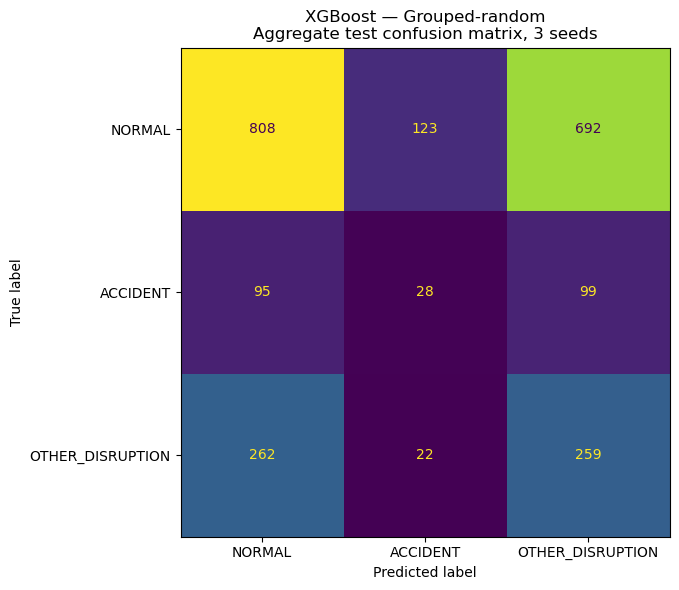

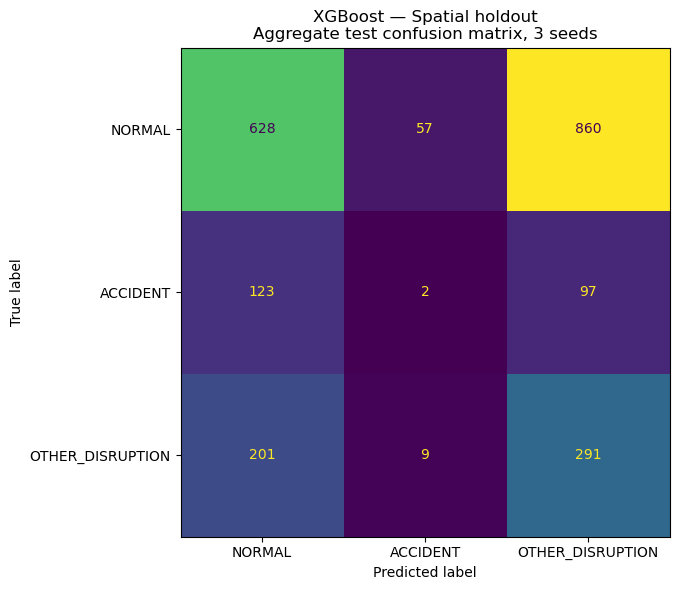

In [10]:

for split_name, _ in SPLITS:
    subset = df_all_predictions[
        (df_all_predictions["split_scheme"] == split_name)
        & (df_all_predictions["partition"] == "test")
    ]

    cm_sum = np.zeros((len(CLASS_ORDER), len(CLASS_ORDER)), dtype=int)

    for seed in SEEDS:
        seed_df = subset[subset["seed"] == seed]
        cm_sum += confusion_matrix(
            seed_df["y_true"],
            seed_df["y_pred"],
            labels=CLASS_ORDER,
        )

    fig, ax = plt.subplots(figsize=(7, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm_sum,
        display_labels=CLASS_ORDER,
    )
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"XGBoost — {split_name}\nAggregate test confusion matrix, 3 seeds")
    fig.tight_layout()
    plt.show()


## 9. Early-stopping curves for seed 42

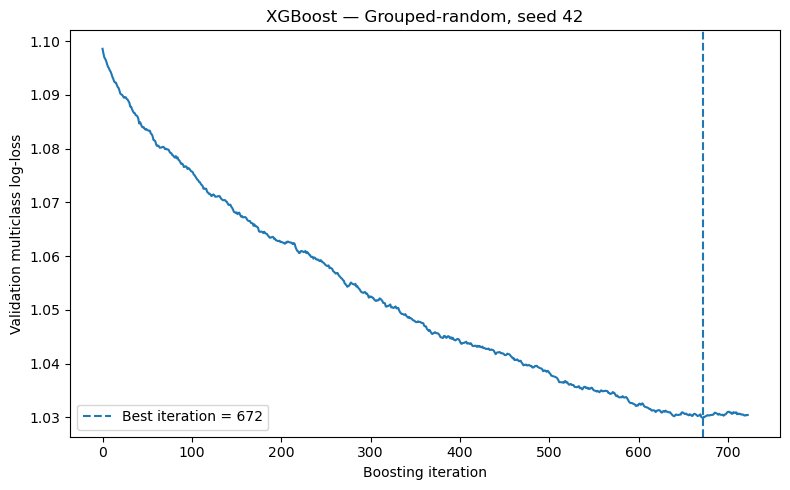

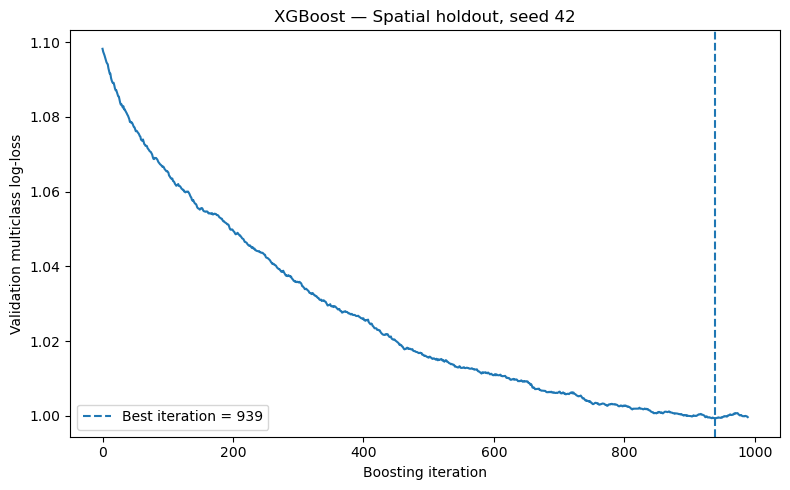

In [11]:

for split_name in ["Grouped-random", "Spatial holdout"]:
    hist_df = all_histories[(split_name, 42)]
    model = all_models[(split_name, 42)]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(hist_df["iteration"], hist_df["validation_mlogloss"])
    ax.axvline(
        model.best_iteration,
        linestyle="--",
        label=f"Best iteration = {model.best_iteration}",
    )
    ax.set_title(f"XGBoost — {split_name}, seed 42")
    ax.set_xlabel("Boosting iteration")
    ax.set_ylabel("Validation multiclass log-loss")
    ax.legend()
    fig.tight_layout()
    plt.show()


## 10. Feature importance

,split_scheme,feature,mean,std
13,Grouped-random,post_mean,0.036450,0.001559
16,Grouped-random,pre_median,0.036040,0.001007
7,Grouped-random,logflow_t0,0.035866,0.001694
8,Grouped-random,max_abs_change,0.035575,0.001006
0,Grouped-random,cumulative_post_change,0.035505,0.002558
26,Grouped-random,window_mean,0.035323,0.000220
14,Grouped-random,post_slope,0.034896,0.001386
3,Grouped-random,logflow_m3,0.034330,0.001247
11,Grouped-random,mean_shift,0.034286,0.000414
25,Grouped-random,window_max,0.034004,0.001812


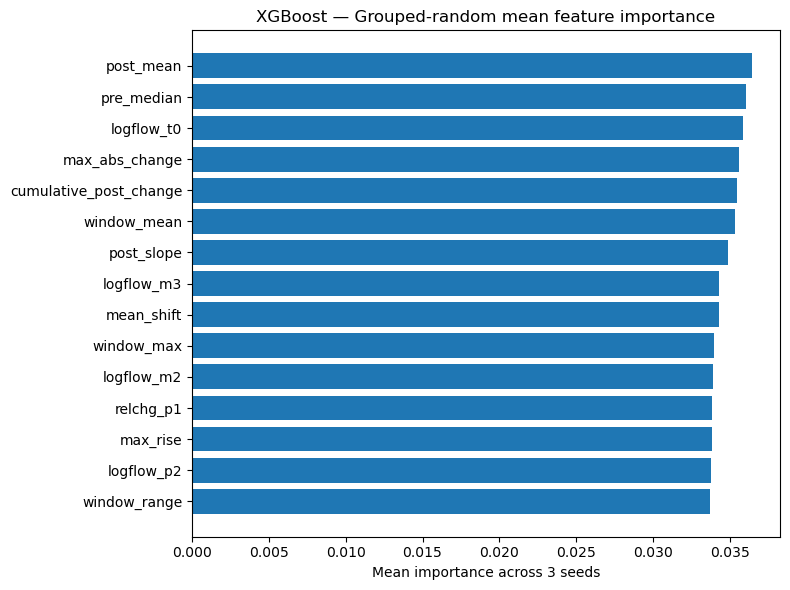

,split_scheme,feature,mean,std
45,Spatial holdout,pre_mean,0.036994,0.000522
43,Spatial holdout,post_mean,0.036698,0.001938
59,Spatial holdout,window_std,0.035476,0.000336
46,Spatial holdout,pre_median,0.035290,0.001431
56,Spatial holdout,window_mean,0.034752,0.000564
52,Spatial holdout,relchg_p2,0.034505,0.000947
37,Spatial holdout,logflow_t0,0.034273,0.001326
41,Spatial holdout,mean_shift,0.034242,0.000234
58,Spatial holdout,window_range,0.034075,0.000299
35,Spatial holdout,logflow_p2,0.033803,0.000378


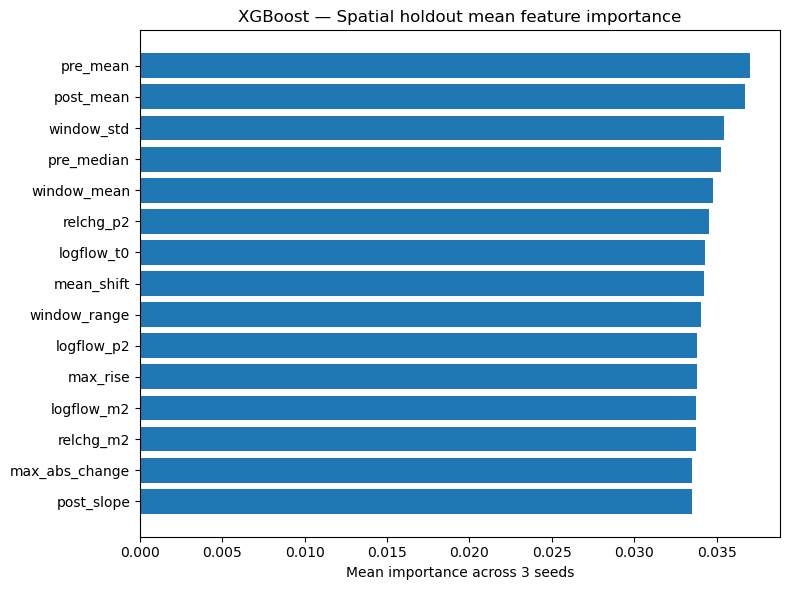

In [12]:

feature_names = build_aligned_features(canonical).columns.tolist()

importance_rows = []

for (split_name, seed), model in all_models.items():
    for feature, importance in zip(feature_names, model.feature_importances_):
        importance_rows.append({
            "split_scheme": split_name,
            "seed": seed,
            "feature": feature,
            "importance": importance,
        })

importance_df = pd.DataFrame(importance_rows)

importance_summary = (
    importance_df
    .groupby(["split_scheme", "feature"])["importance"]
    .agg(["mean", "std"])
    .reset_index()
)

importance_summary.to_csv(
    OUTPUT_DIR / "xgboost_feature_importance_mean_sd.csv",
    index=False,
)

for split_name, _ in SPLITS:
    top = (
        importance_summary[importance_summary["split_scheme"] == split_name]
        .sort_values("mean", ascending=False)
        .head(15)
        .sort_values("mean")
    )

    display(top.sort_values("mean", ascending=False))

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top["feature"], top["mean"])
    ax.set_title(f"XGBoost — {split_name} mean feature importance")
    ax.set_xlabel("Mean importance across 3 seeds")
    fig.tight_layout()
    plt.show()



## Reporting guidance

Use:

- `xgboost_final_test_summary_mean_sd.csv`
- `xgboost_per_class_summary_mean_sd.csv`

for the final benchmark table and class-level interpretation.

Primary metric:
- test Macro-F1 mean ± SD across seeds 42, 52, and 62.

Aligned XGBoost settings:
- same 7-hour window;
- same 2-channel representation as the other final baselines;
- same fixed summary features as Decision Tree and Random Forest;
- balanced training sample weights;
- maximum 2,000 boosting rounds;
- early stopping after 50 rounds without validation log-loss improvement;
- validation Macro-F1 for model selection;
- frozen test split used only for final evaluation.
